# Cardiac Pathology Prediction (IMA205 Challenge 2025)
## Mariana OLM REZENDE

### Index
[1. Introduction](#introduction)  
[2. Importing packages and data](#importing-packages-and-data)  
[3. Exploratory Data Analysis (EDA)](#exploratory-data-analysis-eda)  
[4. Missing Segmentation (LV)](#lv-segmentation)  
[5. Metrics and Features](#metrics-and-features)  
[6. Model](#model)  
[7. Conclusion](#conclusion)

# 1. Introduction <a name="introduction"></a>

The goal of the challenge is to classify subjects based on their CMRI exams among five different diagnostic classes:

0. Healthy controls
1. Myocardial infarction
2. Dilated cardiomyopathy
3. Hypertrophic cardiomyopathy
4. Abnormal right ventricle

# 2. Importing packages, functions and data <a name="importing-packages-and-data"></a>

## Packages

In [1]:
import pandas as pd
import numpy as np
import random

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns


import os
import nibabel as nib

## Functions

In [2]:
def data_to_dict(path):
    """
    Loads ED, ES, and their segmentations for each subject folder inside path.

    Returns:
        data_dict: A dictionary of the form:
            data_dict[subject_name] = {
                'ED': nib.Nifti1Image,
                'ES': nib.Nifti1Image,
                'ED_seg': nib.Nifti1Image,
                'ES_seg': nib.Nifti1Image
            }
    """
    
    data_dict = {}

    for subject_folder in os.listdir(path):
        subject_path = os.path.join(path, subject_folder)
        
        if os.path.isdir(subject_path):
            ed_path     = os.path.join(subject_path, f"{subject_folder}_ED.nii")
            es_path     = os.path.join(subject_path, f"{subject_folder}_ES.nii")
            ed_seg_path = os.path.join(subject_path, f"{subject_folder}_ED_seg.nii")
            es_seg_path = os.path.join(subject_path, f"{subject_folder}_ES_seg.nii")
            
            if all(os.path.isfile(path) for path in [ed_path, es_path, ed_seg_path, es_seg_path]):
                ed_img     = nib.load(ed_path)
                es_img     = nib.load(es_path)
                ed_seg_img = nib.load(ed_seg_path)
                es_seg_img = nib.load(es_seg_path)

                data_dict[subject_folder] = {
                    'ED': ed_img,
                    'ES': es_img,
                    'ED_seg': ed_seg_img,
                    'ES_seg': es_seg_img
                }

    return data_dict

def get_volumetric_image(subject_data):

    ed_img = subject_data['ED'].get_fdata()
    es_img = subject_data['ES'].get_fdata()
    ed_seg = subject_data['ED_seg'].get_fdata()
    es_seg = subject_data['ES_seg'].get_fdata()

    return ed_img, es_img, ed_seg, es_seg

def get_header(subject_data):

    ed_header = subject_data['ED'].header
    es_header = subject_data['ES'].header
    ed_seg_header = subject_data['ED_seg'].header
    es_seg_header = subject_data['ES_seg'].header

    return ed_header, es_header, ed_seg_header, es_seg_header

## Data

In [3]:
path_data = 'Dataset/'
path_train = path_data + 'Train'
path_test = path_data + 'Test'

### MetaData

In [4]:
df_metadata_train = pd.read_csv(path_data + 'metaDataTrain.csv')
df_metadata_test = pd.read_csv(path_data + 'metaDataTest.csv')

### NIfTI Data

In [5]:
nifti_train_dict = data_to_dict(path_train)
list_keys_train = list(nifti_train_dict.keys())

nifti_test_dict = data_to_dict(path_test)
list_keys_test = list(nifti_test_dict.keys())

# 3. Exploratory Data Analysis (EDA) <a name="exploratory-data-analysis-eda"></a>


## MetaData

In [6]:
df_metadata_train.head()

,Id,Category,Height,Weight
0,1,2,184.0,95.0
1,2,2,160.0,70.0
2,3,2,165.0,77.0
3,4,2,159.0,46.0
4,5,2,165.0,77.0


In [7]:
pd.DataFrame(df_metadata_train['Category'].sort_values(ascending=True).value_counts())

,count
Category,
0,20
1,20
2,20
3,20
4,20


**Boxplot:** Height and Weight by Diagnostic Classes

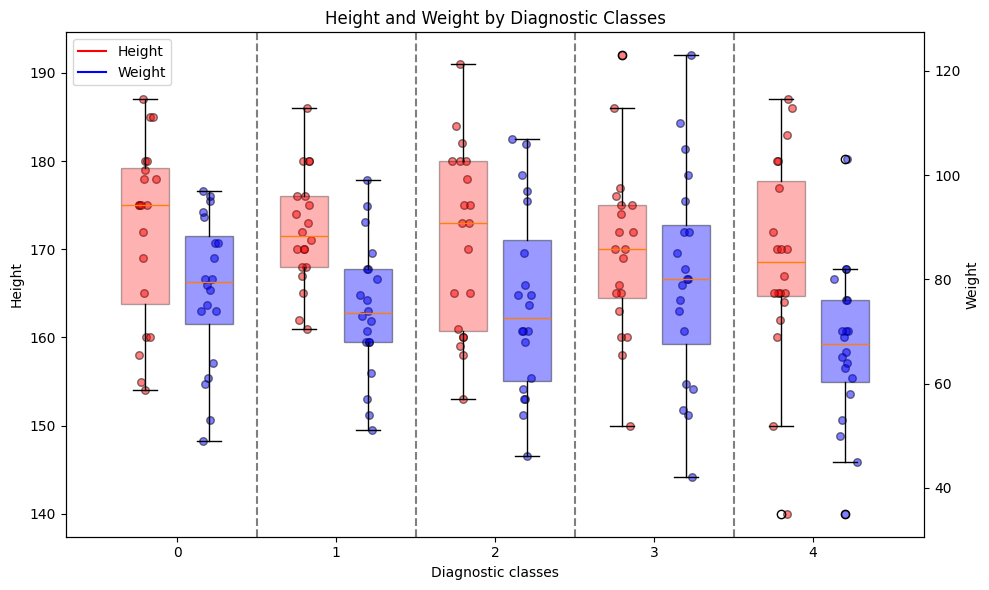

In [8]:
cats = sorted(df_metadata_train['Category'].unique())
xvals = np.arange(len(cats))

height_data = [df_metadata_train.loc[df_metadata_train['Category'] == c, 'Height'].values for c in cats]
weight_data = [df_metadata_train.loc[df_metadata_train['Category'] == c, 'Weight'].values for c in cats]

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()
offset = 0.2

bp1 = ax1.boxplot(
    height_data,
    positions=xvals - offset,
    widths=0.3,
    patch_artist=True)

for patch in bp1['boxes']:
    patch.set_facecolor('red')
    patch.set_alpha(0.3)

for i, cat_heights in enumerate(height_data):
    x_jitter = np.random.normal(loc=xvals[i] - offset, scale=0.03, size=len(cat_heights))
    ax1.scatter(x_jitter, cat_heights, color='red', edgecolors='k', alpha=0.5, s=30)

bp2 = ax2.boxplot(
    weight_data,
    positions=xvals + offset,
    widths=0.3,
    patch_artist=True)

for patch in bp2['boxes']:
    patch.set_facecolor('blue')
    patch.set_alpha(0.4)

for i, cat_weights in enumerate(weight_data):
    x_jitter = np.random.normal(loc=xvals[i] + offset, scale=0.03, size=len(cat_weights))
    ax2.scatter(x_jitter, cat_weights, color='blue', edgecolors='k', alpha=0.5, s=30)

ax1.set_xticks(xvals)
ax1.set_xticklabels(cats)
for boundary in xvals[1:]:
    ax1.axvline(boundary - 0.5, color='k', linestyle='--', alpha=0.5)

ax1.set_xlabel('Diagnostic classes')
ax1.set_ylabel('Height')
ax2.set_ylabel('Weight')
ax1.set_title('Height and Weight by Diagnostic Classes')
ax1.plot([], c='red', label='Height')
ax1.plot([], c='blue', label='Weight')
ax1.legend(loc='upper left')

plt.tight_layout()
plt.show()

## NIfTI Data

Each <nibabel.nifti1.Nifti1Image> object essentially wraps:
* **Volumetric Image Data** (the raw voxel intensities) – typically a NumPy array of shape (X, Y, Z), or (X, Y, Z, Time).
* **Affine** (a 4×4 transformation matrix) – mapping voxel indices to real-world (scanner) coordinates.
* **Header/Metadata** – including voxel dimensions (spacing), data type, acquisition parameters, etc.

### Volumetric Image Data

For each subject, **two images** are provided at two different time points along the cardiac cycle: one image at end **diastole** (end of dilation) and one image at end **systole** (end of contraction) and also their segmentations:
* ED.nii is the end diastole volume
* ES.nii is the end systole volume
* ED_seg.nii is the end diastole segmentation
* ES_seg.nii is the end systole segmentation


Each **segmentation map** consists in a 3D multi-label mask, where each label stands for the following structures:
* 0 - Background
* 1 - Right ventricle cavity (Red)
* 2 - Myocardium (Green)
* 3 - Left ventricle cavity (Blue)



#### Visualizing the data

In [9]:
random_index = random.choice(list_keys_train)

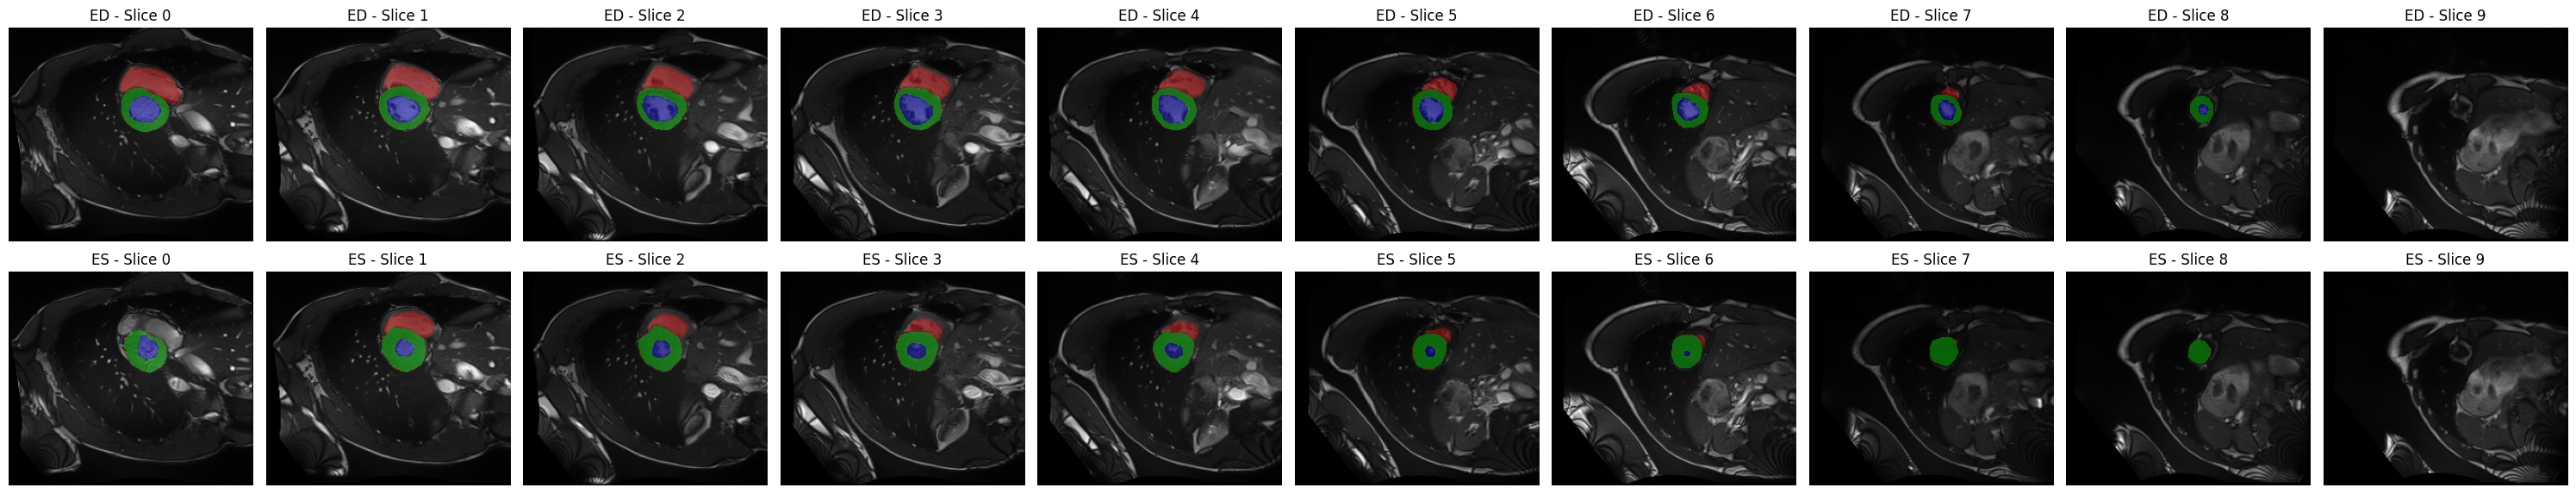

In [10]:
subject_data = nifti_train_dict[random_index]
ed_img, es_img, ed_seg, es_seg = get_volumetric_image(subject_data)


label_cmap = mcolors.ListedColormap([
    (0.0, 0.0, 0.0, 0.0),
    (1.0, 0.0, 0.0, 0.6),
    (0.0, 1.0, 0.0, 0.6), 
    (0.0, 0.0, 1.0, 0.6) 
])


n_slices = ed_img.shape[-1]
fig, axes = plt.subplots(nrows=2, ncols=n_slices, figsize=(3*n_slices, 6))

for i in range(n_slices):
    # ED 
    axes[0, i].imshow(ed_img[:, :, i], cmap='gray', alpha=1.0)
    axes[0, i].imshow(ed_seg[:, :, i], cmap=label_cmap, vmin=0, vmax=3, alpha=0.6)
    axes[0, i].set_title(f"ED - Slice {i}")
    axes[0, i].axis('off')

    # ES 
    axes[1, i].imshow(es_img[:, :, i], cmap='gray', alpha=1.0)
    axes[1, i].imshow(es_seg[:, :, i], cmap=label_cmap, vmin=0, vmax=3, alpha=0.6)
    axes[1, i].set_title(f"ES - Slice {i}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

#### **Histogram:** Number of slices

All subjects have matching slice counts for ED, ES, and segmentations.



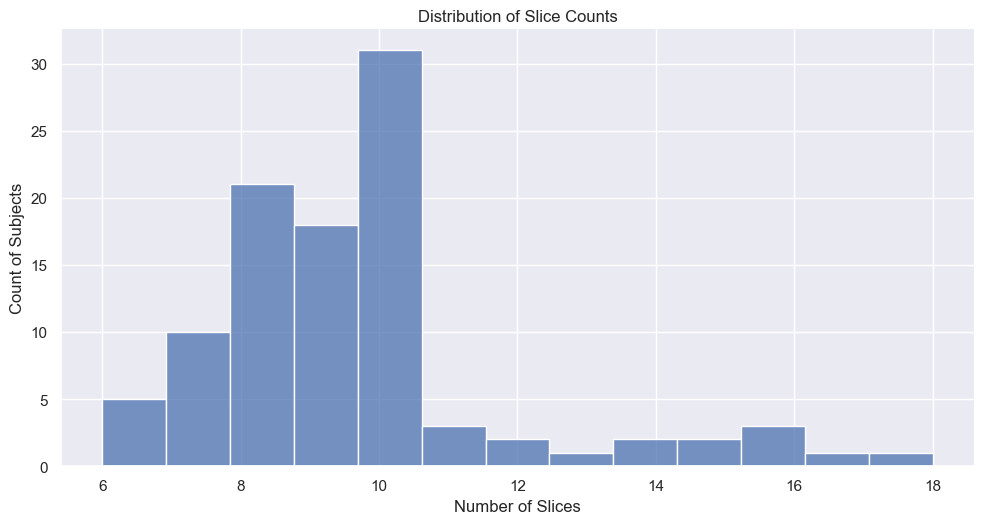

In [11]:
number_slices = []
mismatched_subjects = []

for index in list_keys_train:
    subject_data = nifti_train_dict[index]
    ed_img, es_img, ed_seg, es_seg = get_volumetric_image(subject_data)

    n_slices = ed_img.shape[-1]
    number_slices.append(n_slices)

    if not (ed_img.shape[-1] == es_img.shape[-1] == ed_seg.shape[-1] == es_seg.shape[-1]):
        mismatched_subjects.append(subj_id)

if mismatched_subjects:
    print("Subjects with inconsistent shapes:", mismatched_subjects)
else:
    print("All subjects have matching slice counts for ED, ES, and segmentations.\n")

sns.set();
sns.displot(number_slices, bins=len(np.unique(number_slices)), aspect=2);
plt.xlabel("Number of Slices")
plt.ylabel("Count of Subjects")
plt.title("Distribution of Slice Counts")
plt.show()

#### Number of segmentated structures
Dataframe showing how many volumes contain each labeled structure (Background, Right ventricle cavity, Myocardium, Left ventricle cavity) in the ED and ES phases for both training and testing data.

In [12]:
train_ed_layer_counts = np.zeros(4, dtype=int)
train_es_layer_counts = np.zeros(4, dtype=int)
test_ed_layer_counts  = np.zeros(4, dtype=int)
test_es_layer_counts  = np.zeros(4, dtype=int)

dict_layers = {
    '0': 'Background',
    '1': 'Right ventricle cavity',
    '2': 'Myocardium',
    '3': 'Left ventricle cavity'
}

labels = [0, 1, 2, 3]
layer_names = [dict_layers[str(l)] for l in labels]

for index in list_keys_train:
    subject_data = nifti_train_dict[index]
    ed_img, es_img, ed_seg, es_seg = get_volumetric_image(subject_data)

    # Check presence of each label in ED / ES
    unique_ed = np.unique(ed_seg)
    unique_es = np.unique(es_seg)
    
    for label in labels:
        if label in unique_ed:
            train_ed_layer_counts[label] += 1
        if label in unique_es:
            train_es_layer_counts[label] += 1

for index in list_keys_test:
    subject_data = nifti_test_dict[index]
    ed_img, es_img, ed_seg, es_seg = get_volumetric_image(subject_data)

    unique_ed = np.unique(ed_seg)
    unique_es = np.unique(es_seg)
    
    for label in labels:
        if label in unique_ed:
            test_ed_layer_counts[label] += 1
        if label in unique_es:
            test_es_layer_counts[label] += 1

data_array = [
    train_ed_layer_counts,
    train_es_layer_counts,
    test_ed_layer_counts,
    test_es_layer_counts
]

row_index = pd.MultiIndex.from_tuples(
    [
        ("Train", "ED"),
        ("Train", "ES"),
        ("Test",  "ED"),
        ("Test",  "ES")
    ],
    names=["Data Split", "Phase"]
)

df_seg_counts = pd.DataFrame(
    data=data_array,
    index=row_index,
    columns=layer_names
)

display(df_seg_counts)

Background  Right ventricle cavity  Myocardium  \
Data Split Phase                                                   
Train      ED            100                     100         100   
           ES            100                     100         100   
Test       ED             50                      50          50   
           ES             50                      50          50   

                  Left ventricle cavity  
Data Split Phase                         
Train      ED                       100  
           ES                       100  
Test       ED                         0  
           ES                         0

Based on the current data, there is **no segmentation** labeled for the **left ventricle** in any of the **test volumes**.

### Affine

### Header
The most important **header fields** for this project will be:
1) [dim] = [3, 208, 174, 10, 1, 1, 1, 1]
   * dim[0]: number of dimensions
   * dim[1], dim[2], dim[3] = number of voxels along the 3 axes
2) [pixdim] = [1., 1.68269, 1.68269, 5., 1., 1., 1., 1.]
   * pixdim[1], pixdim[2], pixdim[3] give the voxel size in millimeters along the 3 axes
   * the method get_zooms() returns [pixdim[1], pixdim[2], pixdim[3]] 

In [15]:
subject_data = nifti_train_dict[random_index]
ed_header, es_header, ed_seg_header, es_seg_header = get_header(subject_data)

In [16]:
voxel_pixdim = []

for index in list_keys_train:
    subject_data = nifti_train_dict[index]
    ed_header, es_header, ed_seg_header, es_seg_header = get_header(subject_data)

    # Extracting voxel dimensions
    voxel_pixdims = ed_seg_header.get_zooms()
    voxel_pixdim.append(voxel_pixdims)

# 4. Missing Segmentation (LV) <a name="lv-segmentation"></a>

# 5. Metrics and Features <a name="metrics-and-features"></a>

Some of the proposed features by the references are:
* Ejection Fractions (EF)
* Stroke Volumes (SV)
* Left ventricle mass
* Myocardium thickness

This requires accurate delineation of the left ventricular endocardium and epicardium, and of the right ventricular endocardium for both end diastolic (ED) and end systolic (ES) phase instances.

## Volume

Volume of the anatomical structures at two different time points. Explain the volume metric (equation), which volumes it's gonna be used

## Thickness of the Cardiac Muscle


## Ejection Fraction

# 6. Model <a name="model"></a>

## Classification

# 7. Conclusion <a name="conclusion"></a>
